# Showz

## Exploración de datasets

In [92]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
#Carga de datos
visits = pd.read_csv('datasets/visits_log_us.csv')
orders = pd.read_csv('datasets/orders_log_us.csv')
costs = pd.read_csv('datasets/costs_us.csv')

Definiendo una función de exploración

In [94]:
#Definir una funcion para revisar dataframes
def info_df(df):
    print('___________________________________________ Información de Data Frame')
    print(f'                                                                      *')
    df.info() 
    print('___________________________________________ Primeras tres filas')
    print(f'                                                                      *')
    print(df.head(3))
    if df.duplicated().sum() != 0:
        print('__________________________________*  !!!  *_______ Duplicados *')
        print(f'                                                                      *')
        print(f'Total duplicados: {df.duplicated().sum()}')
        print('__________________________________*   !   *Muestra:')
        if df.duplicated().sum() >= 3:
            print(df[df.duplicated()].sample(3))
        else: 
            print(df[df.duplicated()].sample())
            

In [95]:
print('***   Visitas')
info_df(visits)
print('')
print('***   Pedidos')
info_df(orders)
print('')
print('***   Costos')
info_df(costs)

***   Visitas
___________________________________________ Información de Data Frame
                                                                      *
<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 13.7 MB
___________________________________________ Primeras tres filas
                                                                      *
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   

  

La tabla visitas guarda las visitas de los usuarios. De aquí podemos obtener duracion de sesiones, por usuarios, por dispositivos y por fuente.<br> 
La tabla pedidos dice el tiempo de compra y los ingresos por usuario. Este es otro paso del embudo después de las sesiones en la página. De aqui podemos obtener cantidad de compras por usuario y su frecuencia.
La tabla costos dice de que fuente o portal vienen los usuarios y los costos de esa fuente de publicidad ese dia. Esto se puede comparar con los usuarios que se quedan en la pagina en visits y los que realizan pedidos para saber qué es rentable y qué no. 
Las fechas son de tipo object. Deben ser datetime. Además los nombres de las columnas en visits y orders están muy incómodos, estandarizaremos a snake_case.<br>

### Limpieza de datos

In [96]:
#Funcion para snake case de columnas en df
def fun_snkcs(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_')

#Añadir un '_' a ids (gusto personal y claridad)
def fun_id(df, columna, to_id):
    df.rename(columns={columna:f'{to_id}_id'}, inplace=True)

#Cambiar a datetime
def fun_to_dt(df):
    for col in df.columns:
        if col.endswith('_ts') or col == 'dt':
            df[col] = pd.to_datetime(df[col])

#### Visitas

In [97]:
#Uso de la función para snake_case en visits
fun_snkcs(visits)
#uso de función para ids
fun_id(visits, 'uid', 'user')
#uso de función para tipo de datos de fecha
fun_to_dt(visits)

In [98]:
#revisar visits
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   user_id    359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


#### Pedidos

In [99]:
#Uso de la función para snake_case en orders
fun_snkcs(orders)
#uso de la funcion de ids
fun_id(orders,'uid', 'user')
#uso de funcion para dateime
fun_to_dt(orders)

In [100]:
#revisar orders
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[us]
 1   revenue  50415 non-null  float64       
 2   user_id  50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


#### Costos

In [101]:
#uso de funcion para dateime
fun_to_dt(costs)

In [102]:
#revisar costs
costs.info()

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 59.7 KB


## Preparación de datos

In [103]:
#Definir funcion de estadistica
def distribucion_data(df, columna):
    print('___________________________________________ Descripción estadistica')
    print(f'                                                                      *')
    print(df[columna].describe())
    print('___________________________________________ Dispersión')
    print(f'                                                                      *')
    coef_dispersion = df[columna].std()/df[columna].mean()*100
    mediana = df[columna].median()

    if coef_dispersion < 15:
        print(f'Poca dispersion, {round(coef_dispersion, 3)} %')
    elif coef_dispersion <= 50:
        print(f'Dispersión moderada, {round(coef_dispersion, 3)} %')
    elif coef_dispersion <= 100:
        print(f'Datos muy dispersos, {round(coef_dispersion, 3)} %')
        print(f'La media no representa la mayoria.     * Mediana: {round(mediana,3)}')
    else:
        print(f'Datos extremadamente dispersos, {round(coef_dispersion, 3)} %')
        print(f'La media no representa la mayoria.     * Mediana: {round(mediana,3)}')
    if (df[columna].mean() - round(mediana,3)) > 0:
        print(f'Media - Mediada : {df[columna].mean() - round(mediana,3)}. Sesgo positivo, cola a la derecha')
    elif (df[columna].mean() - round(mediana,3)) < 0:
        print(f'Media - Mediada : {df[columna].mean() - round(mediana,3)}. Sesgo negativo, cola a la izquierda')
    else:
        print('sin sesgo, media=mediana')
    if coef_dispersion <=100 & len(df[columna]) >= 100:
        #histograma
        plt.figure(figsize=(10,2))
        sns.histplot(data=df, x=columna, bins=100, kde=True, alpha=0.5)
        plt.title(f'Histograma de columna: {columna}')
        plt.xlabel(columna)
        plt.ylabel('Frecuencia')
        plt.grid(True)
        plt.show()
    else:
        print('')

Aquí estoy reusando una definición de una función que hice el proyecto pasado, ahora con algunos ajustes. En lugar de bins='fd', que no funciona bien con datos tan dispersos, con 100 bins podemos ver la distribución mucho mejor.

### Visitas

In [104]:
#para recordar las columnas
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   user_id    359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


Hay 359400 registros de visitas como tamaño de muestra. <br>
Extraemos los componentes de fecha en nuevas columnas.

In [105]:
#Componentes de fechas
visits['date'] = visits['start_ts'].dt.date
visits['month'] = visits['start_ts'].dt.month
visits['year'] = visits['start_ts'].dt.year
visits['week'] = visits['start_ts'].dt.isocalendar().week

#Añadimos una columna con la duración de cada visita

In [106]:

visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

In [107]:
print(f"La primer fecha registrada es {visits['start_ts'].min()} y la última es {visits['start_ts'].max()}")

La primer fecha registrada es 2017-06-01 00:01:00 y la última es 2018-05-31 23:59:00


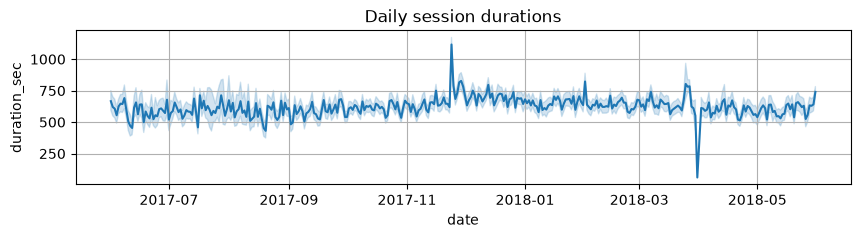

In [108]:
#gráfico de duración de sesiones
#Grafico de Duracion de sesiones
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=visits, x='date', y='duration_sec')
plt.title('Daily session durations')
plt.grid(True)
plt.show()

In [109]:
#uso de función de datos estadisticos
distribucion_data(visits, 'duration_sec')

___________________________________________ Descripción estadistica
                                                                      *
count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: duration_sec, dtype: float64
___________________________________________ Dispersión
                                                                      *
Datos extremadamente dispersos, 157.937 %
La media no representa la mayoria.     * Mediana: 300.0
Media - Mediada : 343.506488592098. Sesgo positivo, cola a la derecha



La duración de la sesiones en promedio duraron 643.51 segundos, pero la media muestra 300 segundos. Hay muchos valores extremos. Pero se puede ver en el percentil 75% que es en el último en el que la duración de las sesiones crece muchísimo por outliers. La desviación estándar es 1016, y están tan dispersos que el valor medio es 300 y la media es casi el doble, 643 segundos.


¿Cuántas personas lo usan cada día, semana y mes?
¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
¿Cuál es la duración de cada sesión?
¿Con qué frecuencia los usuarios regresan?

In [110]:
#Métricas de actividad de usuarios
#al día
dau = visits.groupby('date').agg({'user_id': 'nunique'})
wau = visits.groupby(['year', 'week']).agg({'user_id': 'nunique'})
mau = visits.groupby(['year', 'month']).agg({'user_id': 'nunique'})
#index
dau_plot = dau.reset_index()
wau_plot = wau.reset_index()
mau_plot = mau.reset_index()

Se usa el metodo nunique para contar las incidencias únicas de cada usuario, y señalamos el año en la agrupación para que la información corresponda al mes correcto.

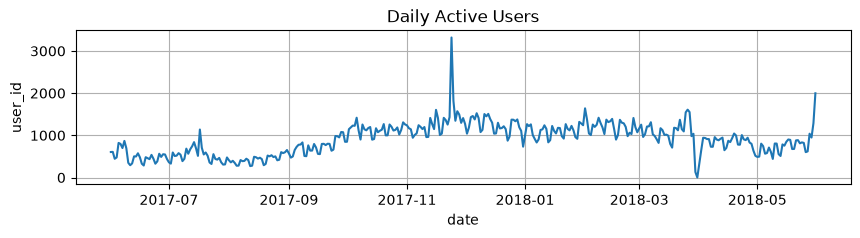

In [111]:
#Gráfico DAU
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=dau_plot, x='date', y='user_id')
plt.title('Daily Active Users')
plt.grid(True)
plt.show()

___________________________________________ Descripción estadistica
                                                                      *
count     364.000000
mean      907.991758
std       370.513838
min         1.000000
25%       594.000000
50%       921.000000
75%      1173.000000
max      3319.000000
Name: user_id, dtype: float64
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 40.806 %
Media - Mediada : -13.008241758241752. Sesgo negativo, cola a la izquierda


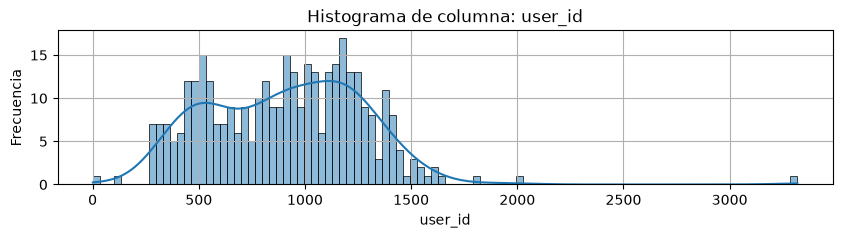

In [112]:
distribucion_data(dau_plot, 'user_id')

En la gráfica de líneas de daily se ven picos interesantes. Entre noviembre 2017 y enero 2018, y de 2018, entre marzo y mayo. <br>
En el histograma vemos la frecuencia de usuarios diarios. En promedio hubo 907.99 usuarios diarios desde 2017 a 2018. En general, lo más frecuente era ver entre 500 y 1500 usuarios diarios, pero hubo algunos casos, menos de 5, donde se registró más de 3000 usuarios diarios.<br>
En el gráfico de líneas podemos ver que este pico de más de 3000 visitas diarias sucedió entre noviembre de 2017 y enero 2018, además, en esas fechas también se registraron las sesiones con duraciones más largas.

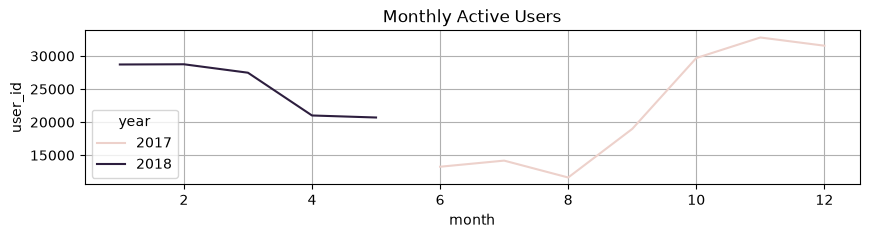

In [113]:
#Gráfico MAU
plt.figure(figsize=(10,2))
#Gráfico de lineas
sns.lineplot(data=mau_plot, x='month', y='user_id', hue='year')
plt.title('Monthly Active Users')
plt.grid(True)
plt.show()

In [114]:
#funcion de distribución para los usuarios activos cada mes
distribucion_data(mau_plot, 'user_id')

___________________________________________ Descripción estadistica
                                                                      *
count       12.000000
mean     23228.416667
std       7546.380462
min      11631.000000
25%      17777.000000
50%      24240.500000
75%      28984.750000
max      32797.000000
Name: user_id, dtype: float64
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 32.488 %
Media - Mediada : -1012.0833333333321. Sesgo negativo, cola a la izquierda



In [115]:
print(f"En promedio hay {dau['user_id'].mean():.2f} usuarios diarios y {wau['user_id'].mean():.2f} usuarios por semana")
print(f"Por mes, en promedio hay {mau['user_id'].mean():.2f} usuarios")

En promedio hay 907.99 usuarios diarios y 5716.25 usuarios por semana
Por mes, en promedio hay 23228.42 usuarios


In [116]:
#Sesiones por periodo
session_by_period = visits.groupby(['year', 'month','week', 'date']).agg(
    {'start_ts':'count'}
)
session_by_period.columns = ['sess_daily']
session_by_period = session_by_period.reset_index() 
sess_weekly = session_by_period.groupby(['year', 'week']).agg({
    'sess_daily':'sum'
}) 
sess_weekly.columns =['n_sess_week']
sess_weekly = sess_weekly.reset_index()
sess_monthly = session_by_period.groupby(['year', 'month']).agg({
    'sess_daily':'sum'
})
sess_monthly.columns =['n_sess_month']
sess_monthly = sess_monthly.reset_index()

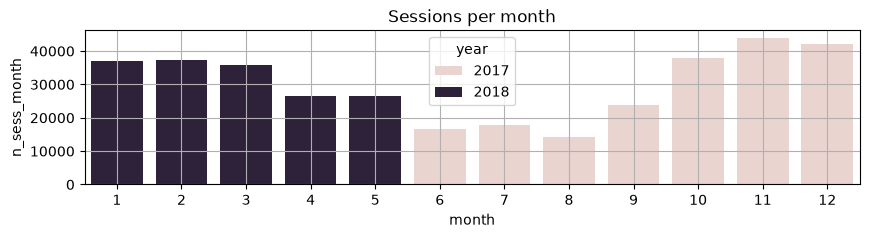

In [117]:
#Visualizacion de sesiones cada mes
plt.figure(figsize=(10,2))
#Gráfico de barras
sns.barplot(data=sess_monthly, x='month', y='n_sess_month', hue='year')
plt.title('Sessions per month')
plt.grid(True)
plt.show()

In [118]:
#describe
print(f"En promedio hay {session_by_period['sess_daily'].mean():.2f} sesiones diarias, {sess_weekly['n_sess_week'].mean():.2f} sesiones por semana y")
print(f"Por mes, {sess_monthly['n_sess_month'].mean():.2f} sesiones")
print(sess_monthly['n_sess_month'].describe())

En promedio hay 987.36 sesiones diarias, 6781.13 sesiones por semana y
Por mes, 29950.00 sesiones
count       12.000000
mean     29950.000000
std      10307.835846
min      14355.000000
25%      22387.250000
50%      31157.000000
75%      37362.250000
max      43969.000000
Name: n_sess_month, dtype: float64


Es un promedio parecido al promedio de dau, pero tiene sentido que este sea un poco mayor ya que algunos usuarios seguramente tienen más de una sesión al día. <br>
Como nota adicional, las instrucicones mencionan datos desde enero 2017 a diciembre de 2018. Pero como hemos visto en las gráficas anteriores, es falso. Es junio 2017 a mayo de 2018. En lugar de dos años, tenemos información de un año. 

In [119]:
#ver df
visits.info()
print(visits.sample(5))

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   device        359400 non-null  str           
 1   end_ts        359400 non-null  datetime64[us]
 2   source_id     359400 non-null  int64         
 3   start_ts      359400 non-null  datetime64[us]
 4   user_id       359400 non-null  uint64        
 5   date          359400 non-null  object        
 6   month         359400 non-null  int32         
 7   year          359400 non-null  int32         
 8   week          359400 non-null  UInt32        
 9   duration_sec  359400 non-null  int32         
dtypes: UInt32(1), datetime64[us](2), int32(3), int64(1), object(1), str(1), uint64(1)
memory usage: 22.3+ MB
         device              end_ts  source_id            start_ts  \
248488  desktop 2017-11-03 23:09:00          5 2017-11-03 23:08:00   
285153  desktop 2017-09-21 16:42:00   

In [120]:
#quitar las columnas que no usaremos
visits_cln = visits[['user_id', 'start_ts', 'year', 'source_id', 'device','duration_sec']]

In [121]:
#ordenar entradas por fecha (para extraer source_id después)
visits_cln_sorted = visits_cln.sort_values('start_ts')
print(visits_cln_sorted.head(5))

                     user_id            start_ts  year  source_id   device  \
308527  13890188992670018146 2017-06-01 00:01:00  2017          5  desktop   
260646  16152015161748786004 2017-06-01 00:02:00  2017          3  desktop   
245715  16706502037388497502 2017-06-01 00:02:00  2017          3  desktop   
235930   8842918131297115663 2017-06-01 00:04:00  2017          3  desktop   
11727   10329302124590727494 2017-06-01 00:09:00  2017          1  desktop   

        duration_sec  
308527            60  
260646             0  
245715           840  
235930             0  
11727            120  


In [122]:
#user_activity: información de usuario:
user_activity = visits_cln_sorted.groupby('user_id').agg({
    'start_ts':['min','count'],
    'source_id':'first',
    'device':'first'
})
user_activity.columns = ['first_visit_ts', 'n_sessions', 'first_source', 'first_device']
user_activity = user_activity.reset_index()
user_activity.info()

<class 'pandas.DataFrame'>
RangeIndex: 228169 entries, 0 to 228168
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         228169 non-null  uint64        
 1   first_visit_ts  228169 non-null  datetime64[us]
 2   n_sessions      228169 non-null  int64         
 3   first_source    228169 non-null  int64         
 4   first_device    228169 non-null  str           
dtypes: datetime64[us](1), int64(2), str(1), uint64(1)
memory usage: 8.7 MB


In [123]:
print(f"En promedio los usuarios tienen { user_activity['n_sessions'].mean()} sesiones y la mediana es { user_activity['n_sessions'].median()}")

En promedio los usuarios tienen 1.5751482453795214 sesiones y la mediana es 1.0


En user_activity se almacenará toda la información de casa user_id. <br>
Por ahora se agrupo visits por usuario y se agregó la primera fecha de visita, primer device, fuente y la cantidad de visitas por usuario.<br>

In [124]:
#Unir visits_cln con user_activity
visits_full = visits_cln.merge(user_activity, on='user_id', how='left')
visits_full['visit_month'] = visits_full['start_ts'].dt.month

In [125]:
visits_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         359400 non-null  uint64        
 1   start_ts        359400 non-null  datetime64[us]
 2   year            359400 non-null  int32         
 3   source_id       359400 non-null  int64         
 4   device          359400 non-null  str           
 5   duration_sec    359400 non-null  int32         
 6   first_visit_ts  359400 non-null  datetime64[us]
 7   n_sessions      359400 non-null  int64         
 8   first_source    359400 non-null  int64         
 9   first_device    359400 non-null  str           
 10  visit_month     359400 non-null  int32         
dtypes: datetime64[us](2), int32(3), int64(3), str(2), uint64(1)
memory usage: 26.0 MB


In [126]:
#funcion de distribucion para revisar el número se sesiones por usuario
distribucion_data(visits_full, 'n_sessions')

___________________________________________ Descripción estadistica
                                                                      *
count    359400.000000
mean         15.283478
std          68.064899
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         893.000000
Name: n_sessions, dtype: float64
___________________________________________ Dispersión
                                                                      *
Datos extremadamente dispersos, 445.35 %
La media no representa la mayoria.     * Mediana: 2.0
Media - Mediada : 13.283478018920423. Sesgo positivo, cola a la derecha



In [127]:
#usuarios con más de 4 visitas al día (percentil 75)
users_returned = visits_full[visits_full['n_sessions'] > 4]

Mayor a 4 porque la mediana es 2 y la media es 15. Pero el percentil 75 llega a 4 sesiones por usuario. Esa es la mayoria de los datos.

In [128]:
#relacion entre los que regresaron y el total
returned_ratio = (users_returned['user_id'].nunique() / visits_full['user_id'].nunique())*100
print(f"Sólo el {returned_ratio} % de todos los usuarios tiene más de 4 sesiones registradas. Eso es {users_returned['user_id'].nunique()} usuarios")


Sólo el 2.9193273406992186 % de todos los usuarios tiene más de 4 sesiones registradas. Eso es 6661 usuarios


Desde agosto de 2017 a diciembre hay un crecimiento en la cantidad de usuarios, pero en 2018 hay una caida de febrero a abril. 

### orders

In [129]:
#recordar df
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[us]
 1   revenue  50415 non-null  float64       
 2   user_id  50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [130]:
#Extraer componentes de fecha
orders['order_date'] = orders['buy_ts'].dt.date
orders['order_month'] = orders['buy_ts'].dt.month
orders['order_year'] = orders['buy_ts'].dt.year

In [131]:
#pedidos por usuario
orders_by_user = orders.groupby('user_id').agg({
    'revenue':'sum', #ingresos por usuario
    'buy_ts':['min','count'] #fecha primera compra y cantidad de compras de usuario
})
orders_by_user.columns = ['ltv_user', 'first_order_ts','n_orders']
orders_by_user = orders_by_user.reset_index()

In [132]:
#calcular la fecha del primer pedido en meses
orders_by_user['first_order_month'] = orders_by_user['first_order_ts'].dt.month
orders_by_user.info()

<class 'pandas.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            36523 non-null  uint64        
 1   ltv_user           36523 non-null  float64       
 2   first_order_ts     36523 non-null  datetime64[us]
 3   n_orders           36523 non-null  int64         
 4   first_order_month  36523 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(1), int64(1), uint64(1)
memory usage: 1.3 MB


In [133]:
#revisando la distribución de la cantidad de pedidos por usuario
distribucion_data(orders_by_user,'n_orders')

___________________________________________ Descripción estadistica
                                                                      *
count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: n_orders, dtype: float64
___________________________________________ Dispersión
                                                                      *
Datos extremadamente dispersos, 250.257 %
La media no representa la mayoria.     * Mediana: 1.0
Media - Mediada : 0.38036305889439537. Sesgo positivo, cola a la derecha



Aquí hay una distribución interesante... hay usuarios que tienen mas de 200 compras registradas, pero son muy pocos. La mayoría solo tiene una. 

In [134]:
#usuarios con mas de una compra
orders_1_greater = orders_by_user[orders_by_user['n_orders'] > 1]
print(len(orders_1_greater))

6292


In [135]:
#relacion entre los que regresaron y el total
order_ratio = (orders_1_greater['user_id'].nunique() / orders_by_user['user_id'].nunique())*100
print(f"Sólo el {order_ratio} % de todos los usuarios tiene más de 1 orden registrada")

Sólo el 17.227500479150123 % de todos los usuarios tiene más de 1 orden registrada


In [136]:
#relacion entre los que regresaron y el total
order_ratio = (orders_1_greater['user_id'].nunique() / orders_by_user['user_id'].nunique())*100
print(f"Sólo el {order_ratio} % de todos los usuarios tiene más de 1 orden registrada")

Sólo el 17.227500479150123 % de todos los usuarios tiene más de 1 orden registrada


In [137]:
#Pedidos por periodo
orders_by_period = orders.groupby(['order_year', 'order_month', 'order_date']).agg(
    {'buy_ts':'count'}
)
orders_by_period.columns = ['orders_daily']
orders_by_period = orders_by_period.reset_index() 

orders_monthly = orders_by_period.groupby(['order_year', 'order_month']).agg({
    'orders_daily':'sum'
})
orders_monthly.columns =['n_orders_month']
orders_monthly = orders_monthly.reset_index()

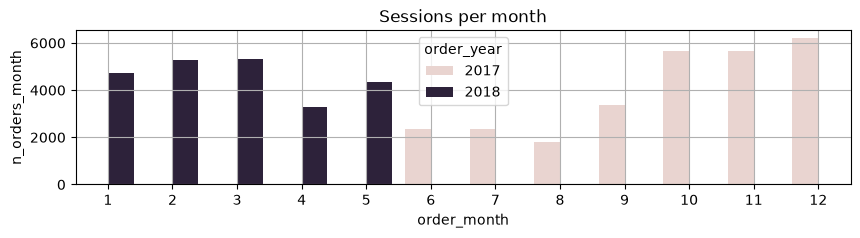

In [138]:
#Visualizacion de sesiones cada mes
plt.figure(figsize=(10,2))
#Gráfico de barras
sns.barplot(data=orders_monthly, x='order_month', y='n_orders_month', hue='order_year')
plt.title('Sessions per month')
plt.grid(True)
plt.show()

In [139]:
distribucion_data(orders_monthly, 'n_orders_month')

___________________________________________ Descripción estadistica
                                                                      *
count      13.000000
mean     3878.076923
std      1858.113401
min         1.000000
25%      2363.000000
50%      4346.000000
75%      5326.000000
max      6218.000000
Name: n_orders_month, dtype: float64
___________________________________________ Dispersión
                                                                      *
Dispersión moderada, 47.913 %
Media - Mediada : -467.92307692307713. Sesgo negativo, cola a la izquierda



In [140]:
#describe
print(f"En promedio hay {orders_by_period['orders_daily'].mean():.2f} pedidos diarios y  {orders_monthly['n_orders_month'].mean():.2f} por mes")

En promedio hay 138.50 pedidos diarios y  3878.08 por mes


In [141]:
#Distribución de las compras por usuario. ltv
distribucion_data(orders_by_user, 'ltv_user')

___________________________________________ Descripción estadistica
                                                                      *
count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: ltv_user, dtype: float64
___________________________________________ Dispersión
                                                                      *
Datos extremadamente dispersos, 1276.979 %
La media no representa la mayoria.     * Mediana: 3.05
Media - Mediada : 3.8513279303452626. Sesgo positivo, cola a la derecha



Sólo muy poco usuarios generan ingresos fuertes

In [142]:
#uniendo con order_activity
orders_full = orders.merge(orders_by_user, on='user_id', how='left')
orders_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   buy_ts             50415 non-null  datetime64[us]
 1   revenue            50415 non-null  float64       
 2   user_id            50415 non-null  uint64        
 3   order_date         50415 non-null  object        
 4   order_month        50415 non-null  int32         
 5   order_year         50415 non-null  int32         
 6   ltv_user           50415 non-null  float64       
 7   first_order_ts     50415 non-null  datetime64[us]
 8   n_orders           50415 non-null  int64         
 9   first_order_month  50415 non-null  int32         
dtypes: datetime64[us](2), float64(2), int32(3), int64(1), object(1), uint64(1)
memory usage: 3.3+ MB


In [143]:
#Tamaño promedio de compras cada mes
month_revenue = orders_full.groupby('order_month').agg({
    'revenue':'mean'
}).reset_index()
distribucion_data(month_revenue, 'revenue')

___________________________________________ Descripción estadistica
                                                                      *
count    12.000000
mean      4.956902
std       0.521307
min       4.059834
25%       4.780459
50%       4.887709
75%       5.333424
max       5.852139
Name: revenue, dtype: float64
___________________________________________ Dispersión
                                                                      *
Poca dispersion, 10.517 %
Media - Mediada : 0.06890193682151491. Sesgo positivo, cola a la derecha



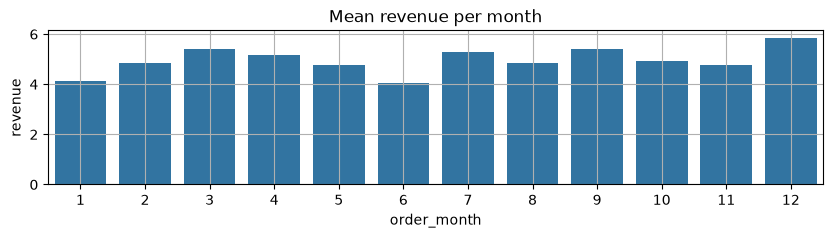

In [144]:
#Visualizacion de tamaño de compra cada mes
plt.figure(figsize=(10,2))
#Gráfico de barras
sns.barplot(data=month_revenue, x='order_month', y='revenue')
plt.title('Mean revenue per month')
plt.grid(True)
plt.show()

In [145]:
print(f"El tamaño promedio de compras o pedidos registrados es de {orders_full['revenue'].mean()} pedidos")

El tamaño promedio de compras o pedidos registrados es de 4.999646930477041 pedidos


El tamaño de compra mensual se ve consitente en general

### Ventas

¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)
¿Cuántos pedidos hacen durante un período de tiempo dado?
¿Cuál es el tamaño promedio de compra?
¿Cuánto dinero traen? (LTV)

### Marketing

¿Cuánto dinero se gastó? (Total/por fuente de adquisición/a lo largo del tiempo)
¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
¿Cuán rentables eran las inversiones? (ROMI)

### Comparación de dispositivos

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo.

## Conclusión

aconseja a los expertos de marketing cuánto dinero invertir y dónde ¿Qué fuentes/plataformas recomendarías? Fundamenta tu selección: ¿en qué métricas te enfocaste? ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?